# Phase 1: Data Understanding & Profiling

This notebook is the first step of the analytics project. It helps us understand the datasets, their structure, data quality, and basic relationships between the data.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

RAW_DIR = r"c:\PYTHON p45\New_Project\data\raw"

files = glob.glob(os.path.join(RAW_DIR, "*.csv"))
csv_files = {os.path.basename(file): file for file in files}

print(f"Found {len(csv_files)} CSV files in {RAW_DIR}")

Found 0 CSV files in c:\PYTHON p45\New_Project\data\raw


## 1. Dataset Inventory & Structural Observations
Loading datasets and determining rows, columns, memory usage, missing values, and duplicate rows.

In [29]:
import pandas as pd

calendar = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\calendar.csv")
charging_sessions = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\charging_sessions.csv")
data_dictionary = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\data_dictionary.csv")
stations = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\stations.csv")
station_hourly_metrics = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\station_hourly_metrics.csv")
traffic = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\traffic.csv")
vehicles = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\vehicles.csv")
weather = pd.read_csv(r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\data\raw\weather.csv")

dataframes = {
    "calendar.csv": calendar,
    "charging_sessions.csv": charging_sessions,
    "data_dictionary.csv": data_dictionary,
    "stations.csv": stations,
    "station_hourly_metrics.csv": station_hourly_metrics,
    "traffic.csv": traffic,
    "vehicles.csv": vehicles,
    "weather.csv": weather
}

print(f"Loaded {len(dataframes)} datasets")

Loaded 8 datasets


In [30]:
inventory = []

for name, df in dataframes.items():
    inventory.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

inventory_df = pd.DataFrame(inventory).sort_values("Rows", ascending=False)

display(inventory_df)

,Dataset,Rows,Columns,Memory (MB),Missing Values,Duplicate Rows
1,charging_sessions.csv,500000,17,273.52,0,0
4,station_hourly_metrics.csv,498253,19,127.35,0,0
5,traffic.csv,498253,6,104.19,0,0
7,weather.csv,17520,10,6.17,0,0
6,vehicles.csv,10000,4,1.37,0,0
3,stations.csv,5000,20,3.25,0,0
0,calendar.csv,731,9,0.20,0,0
2,data_dictionary.csv,31,5,0.01,0,0


### Dataset Size Comparison

This chart compares the number of rows in each dataset. It helps us see which datasets contain more records and which ones are smaller.


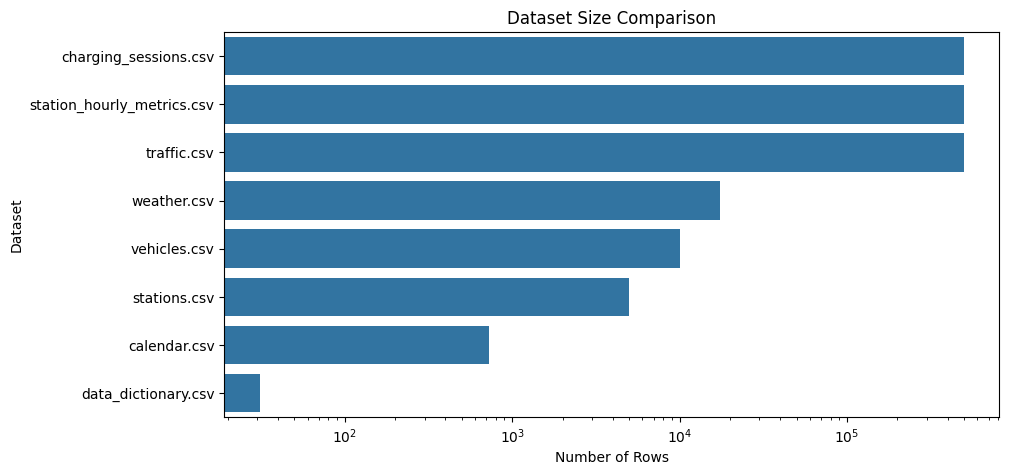

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(data=inventory_df, x="Rows", y="Dataset")

plt.title("Dataset Size Comparison")
plt.xscale("log")
plt.xlabel("Number of Rows")
plt.ylabel("Dataset")

plt.show()

## 2. Table Roles and Relationships

Each dataset has a different role in the project:

* **`charging_sessions.csv`** – Contains individual charging session records.
* **`station_hourly_metrics.csv`** – Contains hourly data for each charging station.
* **`stations.csv`** – Contains information about charging stations and their infrastructure.
* **`vehicles.csv`** – Contains information about the vehicles using the charging stations.
* **`weather.csv`** – Contains weather information by location, date, and hour.
* **`traffic.csv`** – Contains traffic information by station, date, and hour.
* **`calendar.csv`** – Contains date and calendar information.
* **`data_dictionary.csv`** – Describes the columns and fields in the datasets.


## 3. Temporal Coverage

This section checks the date range covered by the main datasets. It helps us understand the time period available for the analysis.

In [32]:
temporal_info = []

for name in ["calendar.csv", "station_hourly_metrics.csv", "weather.csv", "traffic.csv"]:
    if name in dataframes and "Date" in dataframes[name].columns:
        dates = pd.to_datetime(dataframes[name]["Date"])
        
        temporal_info.append({
            "Dataset": name,
            "Start Date": dates.min().date(),
            "End Date": dates.max().date()
        })

# Charging sessions use Start_Time instead of Date
df = dataframes["charging_sessions.csv"]
dates = pd.to_datetime(df["Start_Time"])

temporal_info.append({
    "Dataset": "charging_sessions.csv",
    "Start Date": dates.min().date(),
    "End Date": dates.max().date()
})

temp_df = pd.DataFrame(temporal_info)

display(temp_df)

,Dataset,Start Date,End Date
0,calendar.csv,2024-01-01,2025-12-31
1,station_hourly_metrics.csv,2024-01-01,2025-12-30
2,weather.csv,2024-01-01,2025-12-30
3,traffic.csv,2024-01-01,2025-12-30
4,charging_sessions.csv,2024-01-01,2025-12-30


## 4. Data Quality Observations

This section checks the datasets for missing values, duplicate records, and other basic data issues found during the initial review.


In [33]:
stations = dataframes["stations.csv"]
weather = dataframes["weather.csv"]

print("Station location checks:")
print(f"Negative latitudes: {(stations['Latitude'] < 0).sum()}")
print(f"Negative longitudes: {(stations['Longitude'] < 0).sum()}")

print("\nWeather temperature check:")
print(f"Negative temperatures: {(weather['Temperature_C'] < 0).sum()}")

print("\nLocations in the station data:")
print("Cities:", stations["City"].unique())
print("States:", stations["State"].unique())

Station location checks:
Negative latitudes: 1132
Negative longitudes: 2017

Weather temperature check:
Negative temperatures: 37

Locations in the station data:
Cities: ['Unknown']
States: ['Unknown']


## 5. Important Business Variables

The main variables used in the project are grouped into the following areas:

* **Demand:** `Sessions_Count`, `Charging_Duration_Min`, `Energy_Delivered_kWh`, `Traffic_Volume`
* **Station Performance:** `Utilization_Rate`, `Capacity_Utilization`, `Revenue_USD`, `Peak_Power_kW`
* **Customer Behavior:** `Wait_Time_Min`, `Queue_Length`, `Initial_SOC_pct`, `Final_SOC_pct`
* **External Factors:** `Temperature_C`, `Congestion_Level`, `Rainfall_mm`, `Weather_Condition`
* **Infrastructure:** `Charger_Type`, `Max_Station_Power_kW`, `Number_of_Chargers`


### Distribution of Demand Metrics

These charts show how charging duration and energy delivered are distributed across the charging sessions.


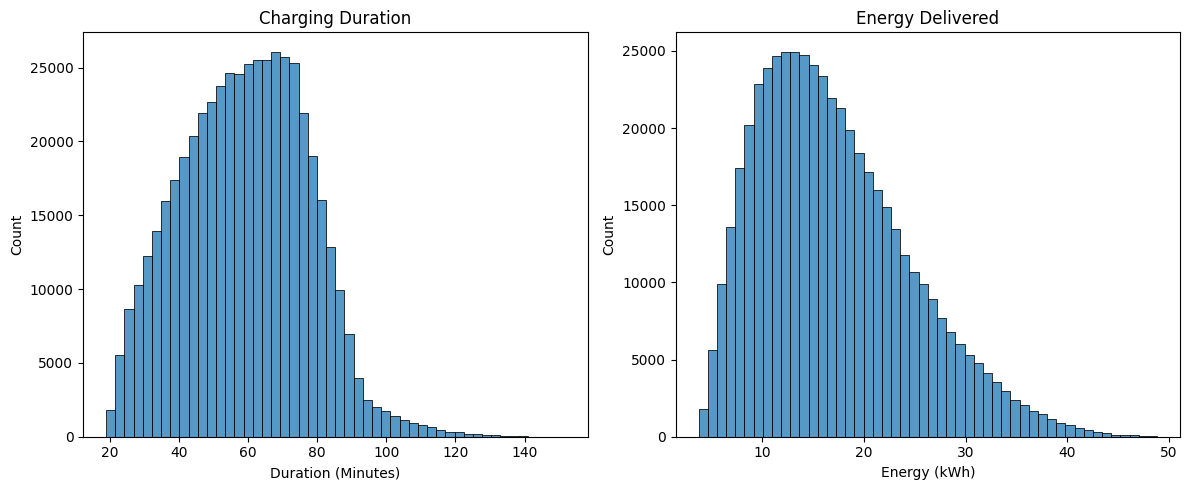

In [34]:
sessions = dataframes["charging_sessions.csv"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(sessions["Charging_Duration_Min"], bins=50, ax=axes[0])
axes[0].set_title("Charging Duration")
axes[0].set_xlabel("Duration (Minutes)")

sns.histplot(sessions["Energy_Delivered_kWh"], bins=50, ax=axes[1])
axes[1].set_title("Energy Delivered")
axes[1].set_xlabel("Energy (kWh)")

plt.tight_layout()
plt.show()

### Summary

The datasets have been reviewed for their structure, size, date range, basic data quality, and key variables. This gives us a clear starting point for the next phase of the project.
